## Dropout

In [3]:
import torch
from torch import nn
from d2l import torch as d2l

### Implementation from Scratch

In [34]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1: return torch.zeros_like(X)
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [4]:
X = torch.arange(16, dtype = torch.float32).reshape((2, 8))
X

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])

In [35]:
print('dropout_p = 0:', dropout_layer(X, 0), '\n')
print('dropout_p = 0.5:', dropout_layer(X, 0.5), '\n')
print('dropout_p = 1:', dropout_layer(X, 1))

dropout_p = 0: tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]]) 

dropout_p = 0.5: tensor([[ 0.,  0.,  0.,  6.,  8.,  0.,  0., 14.],
        [ 0., 18.,  0.,  0.,  0.,  0., 28.,  0.]]) 

dropout_p = 1: tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [36]:
torch.sum(dropout_layer(X, 0)), torch.sum(dropout_layer(X, .5)), 

(tensor(120.), tensor(56.))

### Defining the model

In [37]:
class DropoutMLPScratch(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.lin1 = nn.LazyLinear(num_hiddens_1)
        self.lin2 = nn.LazyLinear(num_hiddens_2)
        self.lin3 = nn.LazyLinear(num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((X.shape[0], -1))))
        if self.training:
            H1 = dropout_layer(H1, self.dropout_1)
        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, self.dropout_2)
        return self.lin3(H2)

### Training

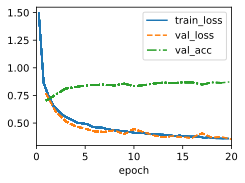

In [39]:
hparams = {'num_outputs':10, 'num_hiddens_1':256, 'num_hiddens_2':256,
           'dropout_1':0.5, 'dropout_2':0.5, 'lr':0.1}
model = DropoutMLPScratch(**hparams)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

### Concise Implementation

In [5]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(num_hiddens_1), nn.ReLU(),
            nn.Dropout(dropout_1), nn.LazyLinear(num_hiddens_2), nn.ReLU(),
            nn.Dropout(dropout_2), nn.LazyLinear(num_outputs))

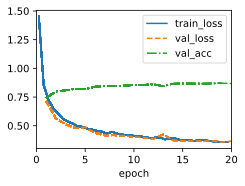

In [41]:
model = DropoutMLP(**hparams)
trainer.fit(model, data)

### Exercises

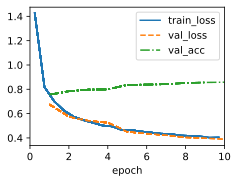

In [43]:
hparams = {'num_outputs':10, 'num_hiddens_1':256, 'num_hiddens_2':256,
           'dropout_1':0.5, 'dropout_2':0.3, 'lr':0.1}

model = DropoutMLP(**hparams)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [45]:
class NoDropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(num_hiddens_1), nn.ReLU(), 
            nn.LazyLinear(num_hiddens_2), nn.ReLU(), nn.LazyLinear(num_outputs))

#### Without Dropout

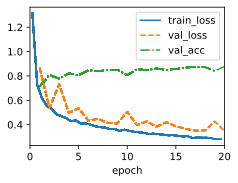

In [47]:
model = NoDropoutMLP(num_outputs=10, num_hiddens_1=256, num_hiddens_2=256, lr=0.1)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

#### With Dropout

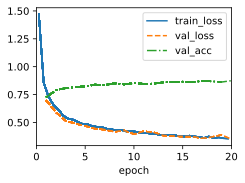

In [8]:
hparams['dropout_2'] = 0.5
model = DropoutMLP(**hparams)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)